<a href="https://colab.research.google.com/github/2005lakshya/lakshya_gupta_eda/blob/main/Lakshya_gupta_eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

In [ ]:
#Loading the dataset
url = "https://raw.githubusercontent.com/salemprakash/EDA/main/Data/bank-full.csv"

bank_data = pd.read_csv(url, sep=';')

print(bank_data.head())

   age        job  marital    education  default housing loan    contact  \
0   56  housemaid  married     basic.4y       no      no   no  telephone   
1   57   services  married  high.school  unknown      no   no  telephone   
2   37   services  married  high.school       no     yes   no  telephone   
3   40     admin.  married     basic.6y       no      no   no  telephone   
4   56   services  married  high.school       no      no  yes  telephone   

  month day_of_week  ...  campaign  pdays  previous     poutcome emp.var.rate  \
0   may         mon  ...         1    999         0  nonexistent          1.1   
1   may         mon  ...         1    999         0  nonexistent          1.1   
2   may         mon  ...         1    999         0  nonexistent          1.1   
3   may         mon  ...         1    999         0  nonexistent          1.1   
4   may         mon  ...         1    999         0  nonexistent          1.1   

   cons.price.idx  cons.conf.idx  euribor3m  nr.employed

In [ ]:
# Applying basic statistical analysis
print("Dataset shape:")
print(bank_data.shape)

print("\nColumn names:")
print(bank_data.columns)

print("\nData types:")
print(bank_data.dtypes)

print("\nNumerical summary:")
print(bank_data.describe())

print("\nComplete summary:")
print(bank_data.describe(include='all'))

print("\nMean age:")
print(bank_data["age"].mean())

print("\nMedian duration:")
print(bank_data["duration"].median())

print("\nMaximum duration:")
print(bank_data["duration"].max())

print("\nMinimum duration:")
print(bank_data["duration"].min())

print("\nStandard deviation:")
print(bank_data["duration"].std())

Dataset shape:
(41188, 21)

Column names:
Index(['age', 'job', 'marital', 'education', 'default', 'housing', 'loan',
       'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx',
       'cons.conf.idx', 'euribor3m', 'nr.employed', 'y'],
      dtype='object')

Data types:
age                 int64
job                object
marital            object
education          object
default            object
housing            object
loan               object
contact            object
month              object
day_of_week        object
duration            int64
campaign            int64
pdays               int64
previous            int64
poutcome           object
emp.var.rate      float64
cons.price.idx    float64
cons.conf.idx     float64
euribor3m         float64
nr.employed       float64
y                  object
dtype: object

Numerical summary:
               age      duration      campaign         pdays      prev

In [ ]:
#Handling missing data
print(bank_data.isnull().sum())

numeric_columns = bank_data.select_dtypes(
    include=['int64', 'float64']
).columns

for column in numeric_columns:
    bank_data[column] = bank_data[column].fillna(
        bank_data[column].mean()
    )

print("\nMissing values after cleaning:")
print(bank_data.isnull().sum())

age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64

Missing values after cleaning:
age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64


In [ ]:
#Data cleaning
bank_data.drop_duplicates(inplace=True)

bank_data.columns = bank_data.columns.str.strip()

print(bank_data.shape)

(41176, 21)


In [ ]:
#Data transformation
bank_data["age_group"] = pd.cut(
    bank_data["age"],
    bins=[0, 30, 45, 60, 100],
    labels=["Young", "Adult", "Middle", "Senior"]
)

bank_data["log_duration"] = np.log1p(
    bank_data["duration"]
)

print(bank_data.head())

   age        job  marital    education  default housing loan    contact  \
0   56  housemaid  married     basic.4y       no      no   no  telephone   
1   57   services  married  high.school  unknown      no   no  telephone   
2   37   services  married  high.school       no     yes   no  telephone   
3   40     admin.  married     basic.6y       no      no   no  telephone   
4   56   services  married  high.school       no      no  yes  telephone   

  month day_of_week  ...  previous     poutcome  emp.var.rate  cons.price.idx  \
0   may         mon  ...         0  nonexistent           1.1          93.994   
1   may         mon  ...         0  nonexistent           1.1          93.994   
2   may         mon  ...         0  nonexistent           1.1          93.994   
3   may         mon  ...         0  nonexistent           1.1          93.994   
4   may         mon  ...         0  nonexistent           1.1          93.994   

  cons.conf.idx  euribor3m  nr.employed   y  age_group  

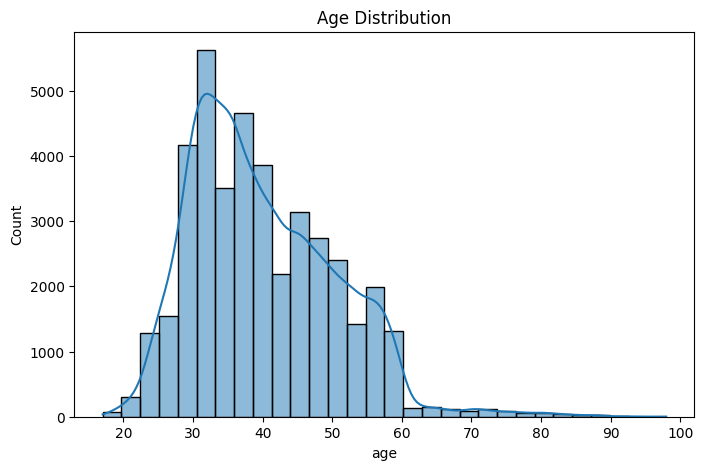

In [ ]:
#Univariate analysis with a minimum of three visualizations
plt.figure(figsize=(8, 5))

sns.histplot(
    bank_data["age"],
    bins=30,
    kde=True
)

plt.title("Age Distribution")
plt.show()

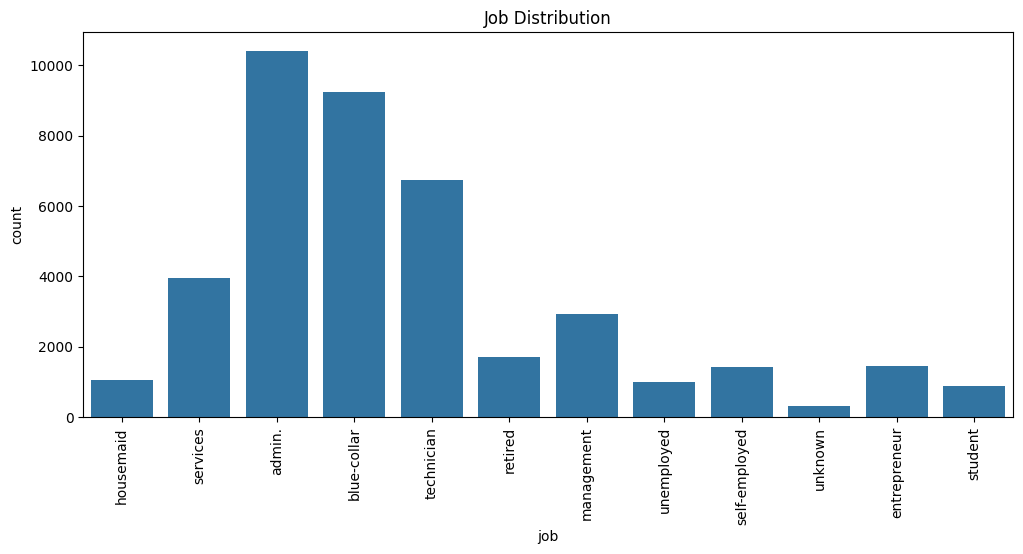

In [ ]:
#Univariate analysis with a minimum of three visualizations
plt.figure(figsize=(12, 5))

sns.countplot(
    x="job",
    data=bank_data
)

plt.xticks(rotation=90)

plt.title("Job Distribution")

plt.show()

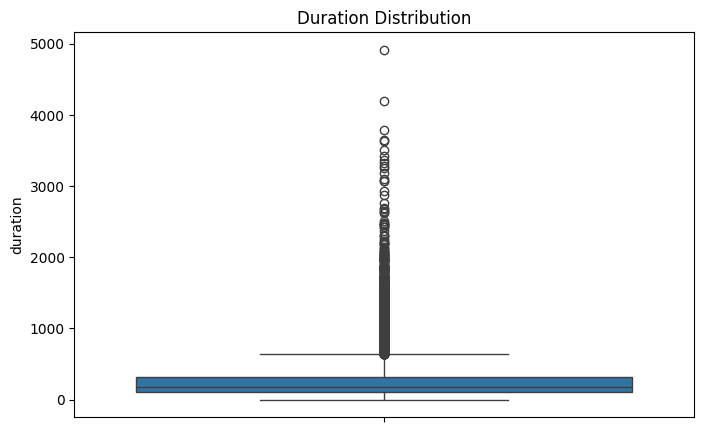

In [ ]:
#Univariate analysis with a minimum of three visualizations
plt.figure(figsize=(8, 5))

sns.boxplot(
    y=bank_data["duration"]
)

plt.title("Duration Distribution")

plt.show()

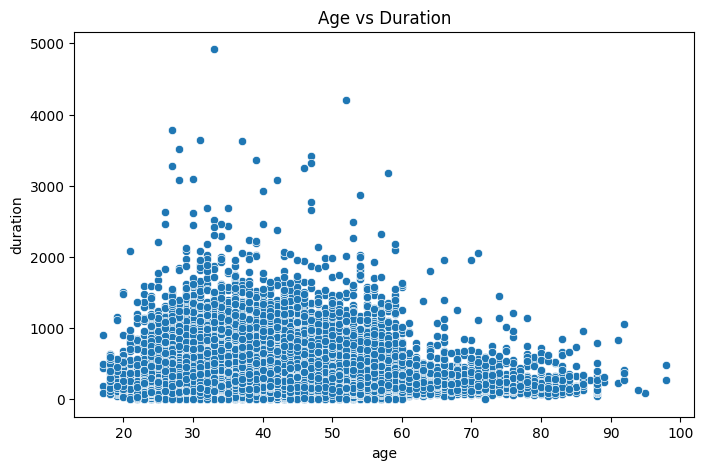

In [ ]:
#Bivariate analysis with a minimum of three visualizations
plt.figure(figsize=(8, 5))

sns.scatterplot(
    x="age",
    y="duration",
    data=bank_data
)

plt.title("Age vs Duration")

plt.show()

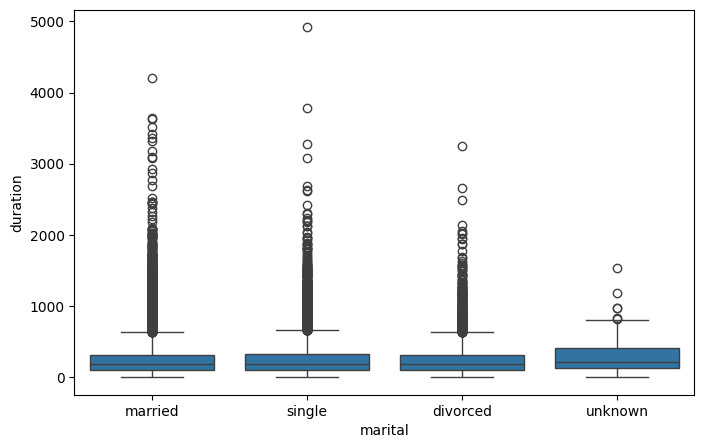

In [ ]:
#Bivariate analysis with a minimum of three visualizations
plt.figure(figsize=(8, 5))

sns.boxplot(
    x="marital",
    y="duration",
    data=bank_data
)

plt.show()

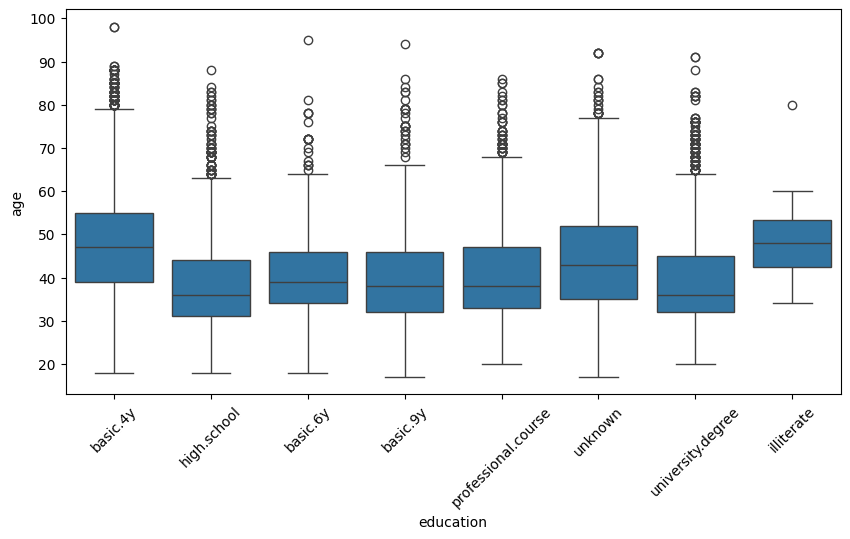

In [ ]:
#Bivariate analysis with a minimum of three visualizations
plt.figure(figsize=(10, 5))

sns.boxplot(
    x="education",
    y="age",
    data=bank_data
)

plt.xticks(rotation=45)

plt.show()

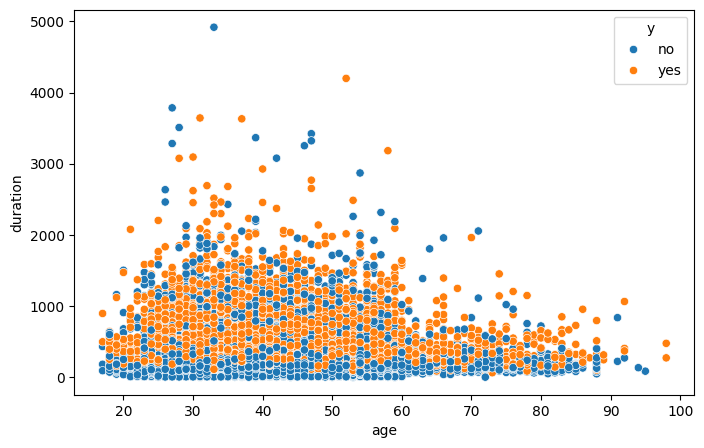

In [ ]:
#Multivariate analysis with a minimum of three visualizations
plt.figure(figsize=(8, 5))

sns.scatterplot(
    x="age",
    y="duration",
    hue="y",
    data=bank_data
)

plt.show()

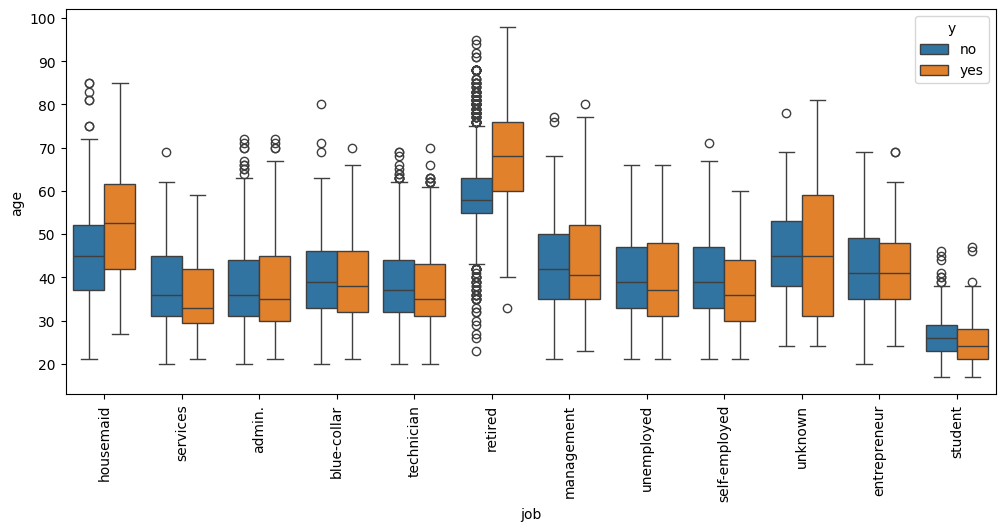

In [ ]:
#Multivariate analysis with a minimum of three visualizations
plt.figure(figsize=(12, 5))

sns.boxplot(
    x="job",
    y="age",
    hue="y",
    data=bank_data
)

plt.xticks(rotation=90)

plt.show()

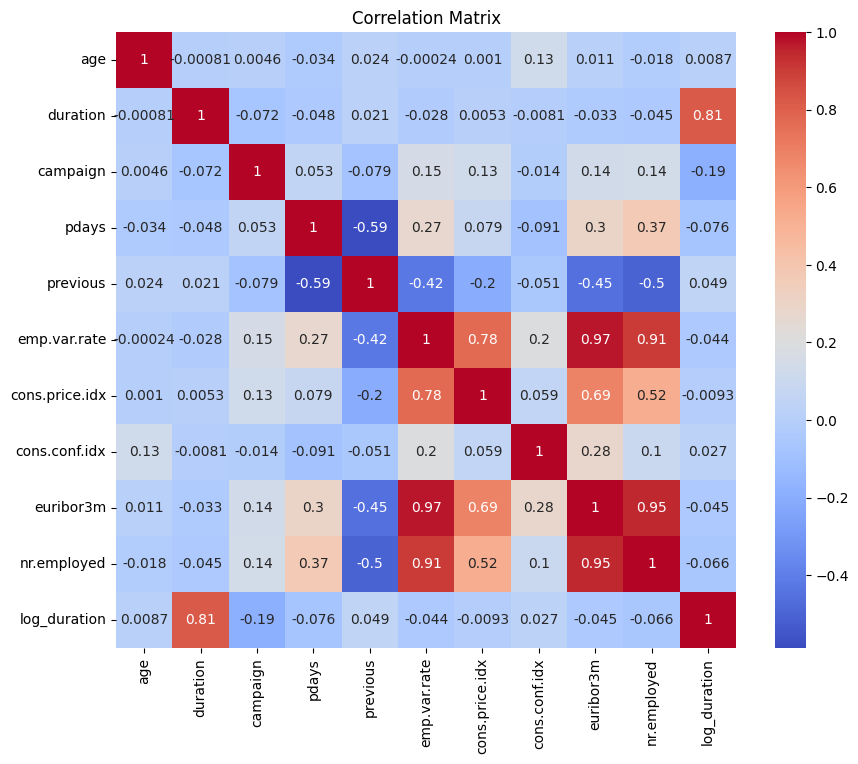

In [ ]:
#Multivariate analysis with a minimum of three visualizations
plt.figure(figsize=(10, 8))

numerical_columns = bank_data.select_dtypes(
    include=["int64", "float64"]
)

correlation_matrix = numerical_columns.corr()

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")

plt.show()